In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
# from sklearn.model_selection import train_test_split

In [2]:
raw_scores_df = pd.read_csv('scores.csv')
df_scores = raw_scores_df.copy()

In [3]:
raw_scores_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Round                      72 non-null     int64  
 1   Game                       72 non-null     int64  
 2   Match                      72 non-null     str    
 3   Score_Team_A               12 non-null     float64
 4   Score_Team_B               12 non-null     float64
 5   prior_to_game_Rank_Team_A  14 non-null     float64
 6   prior_to_game_Rank_Team_B  14 non-null     float64
dtypes: float64(4), int64(2), str(1)
memory usage: 4.1 KB


In [4]:
df_scores['Score_diff'] = abs(df_scores['Score_Team_A'] - df_scores['Score_Team_B'])
df_scores['Rank_diff'] = abs(df_scores['prior_to_game_Rank_Team_A'] - df_scores['prior_to_game_Rank_Team_B'])
df_scores[["Team_A_Name", "Team_B_Name"]] = df_scores["Match"].str.split(
    "_vs_", expand=True
)

print(df_scores.head())

   Round  Game       Match  Score_Team_A  Score_Team_B  \
0      1     1  MEX_vs_RSA           2.0           0.0   
1      1     2  KOR_vs_CZE           2.0           1.0   
2      1     3  CAN_vs_BHI           1.0           1.0   
3      1     4  USA_vs_PAR           4.0           1.0   
4      1     5  QAT_vs_SUI           1.0           1.0   

   prior_to_game_Rank_Team_A  prior_to_game_Rank_Team_B  Score_diff  \
0                       14.0                       60.0         2.0   
1                       25.0                       40.0         1.0   
2                       30.0                       64.0         0.0   
3                       17.0                       41.0         3.0   
4                       56.0                       19.0         0.0   

   Rank_diff Team_A_Name Team_B_Name  
0       46.0         MEX         RSA  
1       15.0         KOR         CZE  
2       34.0         CAN         BHI  
3       24.0         USA         PAR  
4       37.0         QAT     

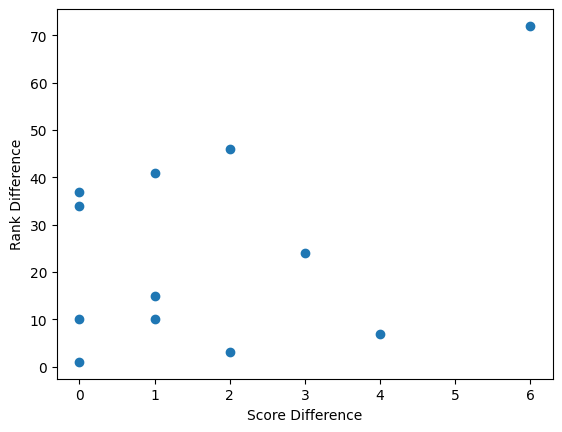

In [5]:
plot_df = df_scores.dropna(subset=['Score_diff', 'Rank_diff'])
plt.scatter(plot_df['Score_diff'], plot_df['Rank_diff'])
plt.xlabel("Score Difference")
plt.ylabel("Rank Difference")
plt.show()

In [ ]:
def predict_matchup(df_scores, timeout_seconds=15):
    # --- 1. INTERACTIVE INPUT (STARTS INSTANTLY) ---
    team_a_input = input("Enter the name of Team A: ").strip()
    team_b_input = input("Enter the name of Team B: ").strip()

    # --- 2. SEPARATE PLAYED GAMES TO TRAIN THE MODEL ---
    played_games = df_scores[df_scores["Score_Team_A"].notna()]

    X_train = played_games[
        ["prior_to_game_Rank_Team_A", "prior_to_game_Rank_Team_B", "Rank_diff"]
    ]
    y_A = played_games["Score_Team_A"]
    y_B = played_games["Score_Team_B"]

    model_A = LinearRegression().fit(X_train, y_A)
    model_B = LinearRegression().fit(X_train, y_B)

    # --- 3. FIND THE UNPLAYED GAME IN THE SAME DF ---
    match_row = df_scores[
        (df_scores["Team_A_Name"] == team_a_input)
        & (df_scores["Team_B_Name"] == team_b_input)
    ]

    if match_row.empty:
        print(
            f"\n❌ Matchup '{team_a_input} vs {team_b_input}' not found in the table."
        )
        print("Note: Ensure spelling matches your dataset exactly.")
        return

    # --- 4. EXTRACT THE RANKS FOR THE UNPLAYED MATCH ---
    new_team_a_rank = match_row["prior_to_game_Rank_Team_A"].iloc[0]
    new_team_b_rank = match_row["prior_to_game_Rank_Team_B"].iloc[0]
    new_rank_diff = match_row["Rank_diff"].iloc[0]

    unplayed_match = pd.DataFrame(
        [[new_team_a_rank, new_team_b_rank, new_rank_diff]],
        columns=[
            "prior_to_game_Rank_Team_A",
            "prior_to_game_Rank_Team_B",
            "Rank_diff",
        ],
    )

    # --- 5. PREDICT AND PRINT ---
    predicted_score_A = round(model_A.predict(unplayed_match)[0])
    predicted_score_B = round(model_B.predict(unplayed_match)[0])

    print("\n=== MATCH PREDICTION ===")
    print(f"{team_a_input} (Rank {new_team_a_rank}): {predicted_score_A:d} points")
    print(f"{team_b_input} (Rank {new_team_b_rank}): {predicted_score_B:d} points")
    print("=========================")

In [ ]:
def predict_matchup(team_a_input, team_b_input, df_scores):
    # --- 1. SEPARATE PLAYED GAMES TO TRAIN THE MODEL ---
    # We filter for rows where 'Score_Team_A' is NOT empty to use as training data
    played_games = df_scores[df_scores["Score_Team_A"].notna()]

    X_train = played_games[
        ["prior_to_game_Rank_Team_A", "prior_to_game_Rank_Team_B", "Rank_diff"]
    ]
    y_A = played_games["Score_Team_A"]
    y_B = played_games["Score_Team_B"]

    model_A = LinearRegression().fit(X_train, y_A)
    model_B = LinearRegression().fit(X_train, y_B)

    # --- 2. FIND THE UNPLAYED GAME IN THE SAME DF ---
    # Look for the row where your columns match your input names
    match_row = df_scores[
        (df_scores["Team_A_Name"] == team_a_input)
        & (df_scores["Team_B_Name"] == team_b_input)
    ]

    if match_row.empty:
        print(
            f"❌ Matchup '{team_a_input} vs {team_b_input}' not found in the table."
        )
        return

    # --- 3. EXTRACT THE RANKS FOR THE UNPLAYED MATCH ---
    new_team_a_rank = match_row["prior_to_game_Rank_Team_A"].iloc[0]
    new_team_b_rank = match_row["prior_to_game_Rank_Team_B"].iloc[0]
    new_rank_diff = match_row["Rank_diff"].iloc[0]

    # Format the data exactly as the model expects it
    unplayed_match = pd.DataFrame(
        [[new_team_a_rank, new_team_b_rank, new_rank_diff]],
        columns=[
            "prior_to_game_Rank_Team_A",
            "prior_to_game_Rank_Team_B",
            "Rank_diff",
        ],
    )

    # --- 4. PREDICT AND PRINT ---
    predicted_score_A = round(model_A.predict(unplayed_match)[0])
    predicted_score_B = round(model_B.predict(unplayed_match)[0])

    print("\n=== MATCH PREDICTION ===")
    print(f"{team_a_input} (Rank {new_team_a_rank}): {predicted_score_A:d} points")
    print(f"{team_b_input} (Rank {new_team_b_rank}): {predicted_score_B:d} points")
    print("=========================")

In [49]:

def get_teams(df_scores, round_num, game_num):
    # 1. Use .loc to filter the rows AND pick the 'Team_A_Name' column
    # We use .iloc[0] at the end to get the clean text instead of a Pandas Series
    team_a = df_scores.loc[
        (df_scores["Round"] == round_num) & (df_scores["Game"] == game_num),
        "Team_A_Name",
    ].iloc[0]

    team_b = df_scores.loc[
        (df_scores["Round"] == round_num) & (df_scores["Game"] == game_num),
        "Team_B_Name",
    ].iloc[0]

    # 2. Print just the single requested Round, Game, and the matching Teams
    print(f"Round: {round_num}, Game: {game_num}")
    print(f"Team A: {team_a}")
    print(f"Team B: {team_b}")

    # Return them so you can use them in your regression code later
    return team_a, team_b

In [51]:
get_teams(df_scores, round_num=1, game_num=13)

Round: 1, Game: 13
Team A: ESP
Team B: CPV


('ESP', 'CPV')

In [52]:
predict_matchup("ESP", "CPV", df_scores)


=== MATCH PREDICTION ===
ESP (Rank 2.0): 5 points
CPV (Rank 67.0): 1 points


In [ ]:
def train_score_predictor(historical_df):
    historical_df["Rank_Difference"] = (
        historical_df["prior_to_game_Rank_Team_A"]
        - historical_df["prior_to_game_Rank_Team_B"]
    )

    X = historical_df[
        [
            "prior_to_game_Rank_Team_A",
            "prior_to_game_Rank_Team_B",
            "Rank_Difference",
        ]
    ]
    y_A = historical_df["Score_Team_A"]
    y_B = historical_df["Score_Team_B"]

    model_A = LinearRegression().fit(X, y_A)
    model_B = LinearRegression().fit(X, y_B)

    return model_A, model_B

In [ ]:
def predict_matchup(team_a_input, team_b_input, unplayed_csv_path, model_A, model_B):

    unplayed_df = pd.read_csv(unplayed_csv_path)

    match_row = unplayed_df[
        (unplayed_df["Team_A_Name"] == team_a_input)
        & (unplayed_df["Team_B_Name"] == team_b_input)
    ]

    if match_row.empty:
        print(
            f"❌ Matchup '{team_a_input} vs {team_b_input}' not found in the schedule."
        )
        return

    rank_a = match_row["prior_to_game_Rank_Team_A"].iloc[0]
    rank_b = match_row["prior_to_game_Rank_Team_B"].iloc[0]
    rank_diff = rank_a - rank_b

    match_features = pd.DataFrame(
        [[rank_a, rank_b, rank_diff]],
        columns=[
            "prior_to_game_Rank_Team_A",
            "prior_to_game_Rank_Team_B",
            "Rank_Difference",
        ],
    )

    pred_score_A = round(model_A.predict(match_features)[0])
    pred_score_B = round(model_B.predict(match_features)[0])

    print("\n=== LIVE MATCH PREDICTION ===")
    print(f"{team_a_input} (Rank {rank_a}): {pred_score_A:d}")
    print(f"{team_b_input} (Rank {rank_b}): {pred_score_B:d}")
    print("=============================")